In [ ]:
import pandas as pd  # used for working table and datasets , Example: reading CSV files, filtering rows, etc.
import numpy as np   # Used for numerical operations (arrays, math calculations, matrices).

In [ ]:
import matplotlib.pyplot as plt     # Used to create graphs and charts (line graph, bar chart, etc.).
from  sklearn.model_selection import train_test_split # Splits your dataset into: *Training data (to train model),*Testing data (to check accuracy)
from sklearn.tree import DecisionTreeClassifier   # A machine learning model used for classification (e.g., predicting yes/no, pass/fail, spam/not spam).
from sklearn.metrics import accuracy_score   # Used to measure how correct your model is (gives percentage of correct predictions).

from sklearn.model_selection import cross_val_score  # Used to test model multiple times for better reliability(instead of just one train-test split).
from sklearn.preprocessing import KBinsDiscretizer   # Converts continuous values into categories (bins) Example: Age → Young / Middle / Old
from sklearn.compose import ColumnTransformer    # Helps apply different transformations to different columns (e.g., scale numbers, encode text).

In [70]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Desktop\New folder (2)\train.csv" ,usecols  = ['Age', 'Fare', 'Survived'])

In [71]:
df.dropna(inplace = True)  # This line removes all rows that have missing values (NaN) from your dataset

In [72]:
df.shape

(714, 3)

In [73]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [74]:
X = df.iloc[:,1:]     # iloc means select data using position (index numbers)
y = df.iloc[:,0]

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [76]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [77]:
clf = DecisionTreeClassifier()

In [78]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [79]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [80]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv = 10,scoring="accuracy"))  # This line calculates the average accuracy of your model using 10-fold cross-validation.
                                                                                   # Splits data into 10 parts (cv=10)
                                                                                   # Trains and tests the model 10 times
                                                                                   # Returns 10 accuracy scores

np.float64(0.6401017214397495)

In [81]:
kbin_age = KBinsDiscretizer(n_bins=5,encode = "ordinal",strategy="kmeans")   # kBinDiscretizer means It is used to convert continuous numerical data into categories (bins).
kbin_fare = KBinsDiscretizer(n_bins=5,encode = "ordinal",strategy="kmeans")  # strategy = "kmeans" Uses K-Means clustering logic to create bins.
                                                                             # In KBinsDiscretizer,encode = "ordinal" means: Convert each bin into a number (label).

In [82]:
kbin_age = KBinsDiscretizer(n_bins=10,encode = "ordinal",strategy="quantile")    # kbin_age = for age  column   
kbin_fare = KBinsDiscretizer(n_bins=10,encode = "ordinal",strategy="quantile")   # kbin_fare = for fare column 

# Binning makes data simpler and structured
# Example:

# Instead of exact age = 23
# You say → “Age group = 20–30”
# A range of values where data points are grouped together.

In [83]:
trf = ColumnTransformer([("first",kbin_age,[0]),("second",kbin_fare,[1])]) # ColumnTransformer  means  Apply different transformations to different columns.
                                                                           # Apply kbin_age on column 0 and kbin_fare on column 1 

In [84]:
X_train_trf = trf.fit_transform(X_train)  
X_test_trf = trf.transform(X_test)

C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [85]:
trf.named_transformers_     # dono transformers ko show karega.

{'first': KBinsDiscretizer(encode='ordinal', n_bins=10),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10)}

In [86]:
trf.named_transformers_["first"].n_bins_  

array([10])

In [87]:
trf.named_transformers_["first"].bin_edges_  

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [88]:
trf.named_transformers_["second"].bin_edges_  

array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [89]:
output = pd.DataFrame({"age":X_train["Age"],"age_trf":X_train_trf[:,0],"fare":X_train["Fare"],"fare_trf":X_train_trf[:,1]})

In [90]:
output["age_labels"] = pd.cut(x=X_train["Age"],bins=trf.named_transformers_["first"].bin_edges_[0].tolist())
output["fare_labels"] = pd.cut(x=X_train["Fare"],bins=trf.named_transformers_["second"].bin_edges_[0].tolist()) 

In [91]:
output.head(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
328,31.0,5.0,20.5250,5.0,"(28.5, 32.0]","(15.75, 26.0]"
73,26.0,4.0,14.4542,4.0,"(25.0, 28.5]","(13.0, 15.75]"
253,30.0,5.0,16.1000,5.0,"(28.5, 32.0]","(15.75, 26.0]"
719,33.0,6.0,7.7750,1.0,"(32.0, 36.0]","(7.75, 7.896]"
666,25.0,4.0,13.0000,4.0,"(22.0, 25.0]","(9.225, 13.0]"


In [92]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [ ]:
accuracy_score(y_test,y_pred2)   

0.6223776223776224

In [94]:
X_trf = trf.fit_transform(X)  
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv = 10,scoring="accuracy"))

C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.682140062597809)

In [95]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode = "ordinal",strategy=strategy)   # kBinDiscretizer means It is used to convert continuous numerical data into categories (bins).
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode = "ordinal",strategy=strategy)  # strategy = "kmeans" Uses K-Means clustering logic to create bins.
                                                                                     # In KBinsDiscretizer,encode = "ordinal" means: Convert each bin into a number (label).

    trf = ColumnTransformer([("first",kbin_age,[0]),("second",kbin_fare,[1])]) # ColumnTransformer  means  Apply different transformations to different columns.
                                                                               # Apply kbin_age on column 0 and kbin_fare on column 1 

    X_trf = trf.fit_transform(X)  
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv = 10,scoring="accuracy")))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X["Age"])
    plt.title("Before")


    plt.subplot(122)
    plt.hist(X_trf[:,0],color="red")
    plt.title("After")

    plt.show()
    

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X["Fare"])
    plt.title("Before")
     
    plt.subplot(122)
    plt.hist(X_trf[:,0],color="red")
    plt.title("Fare")

    plt.show()


C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.682140062597809


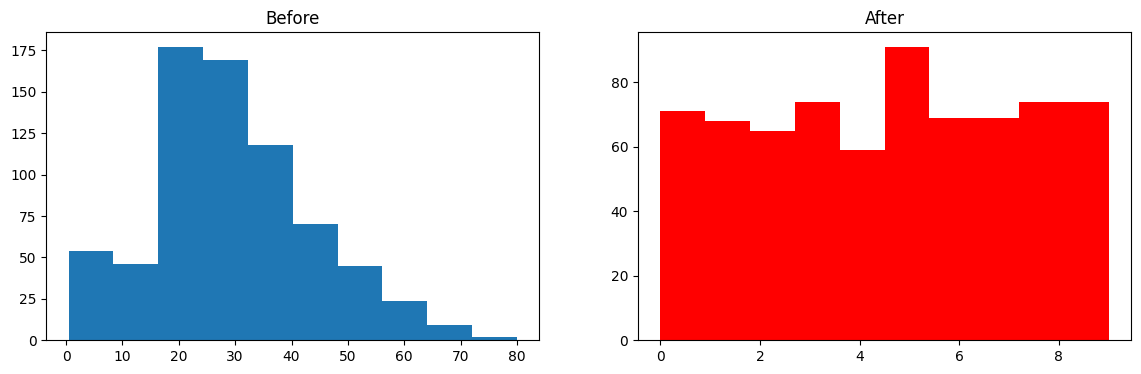

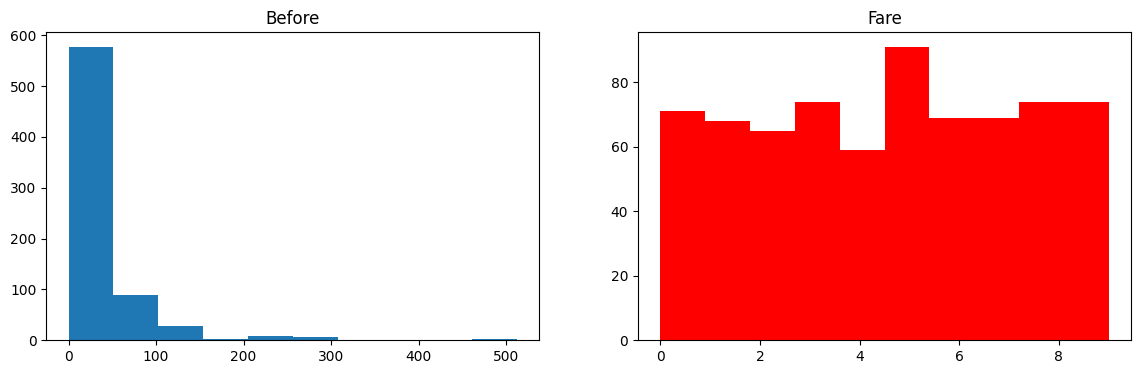

In [96]:
discretize(10,"quantile")

C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.682140062597809


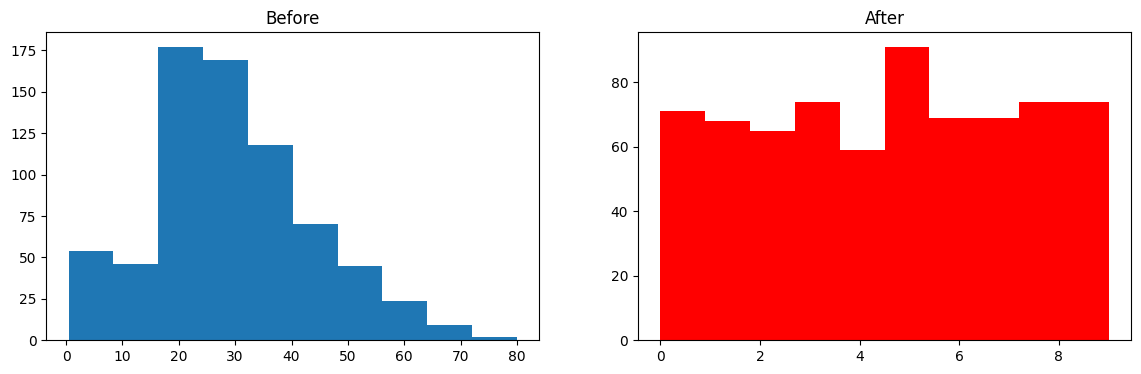

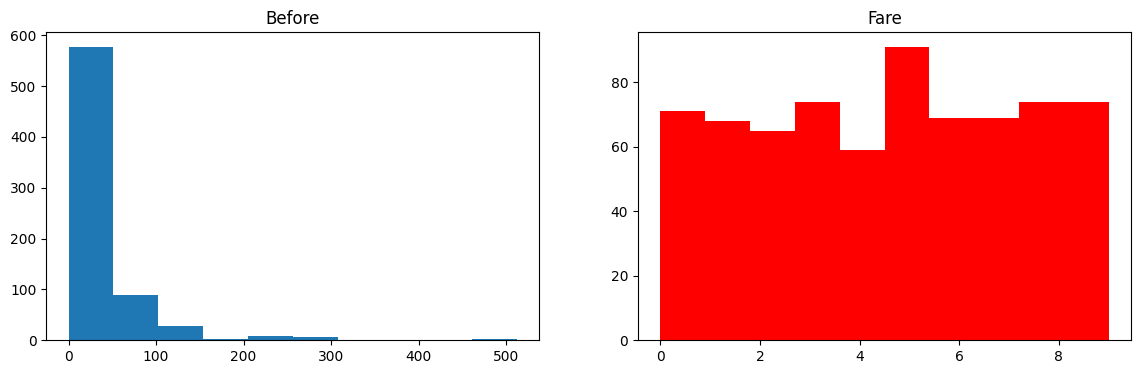

In [97]:
discretize(10,"quantile")

0.6584702660406886


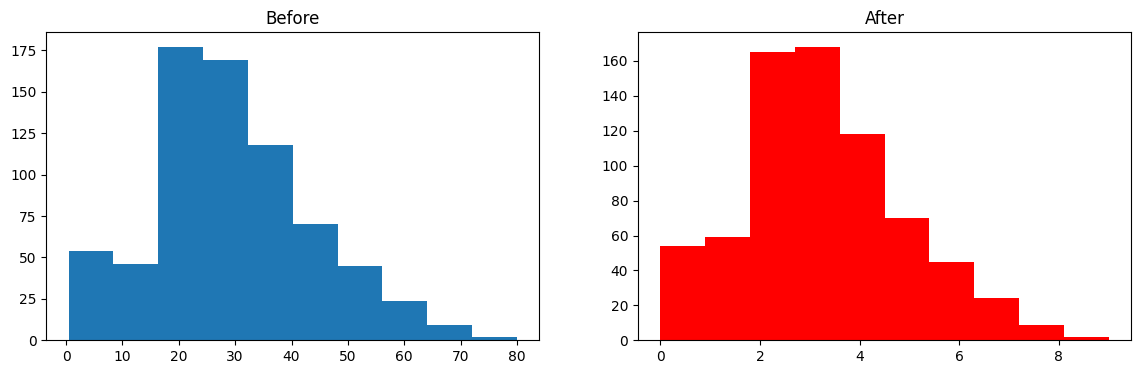

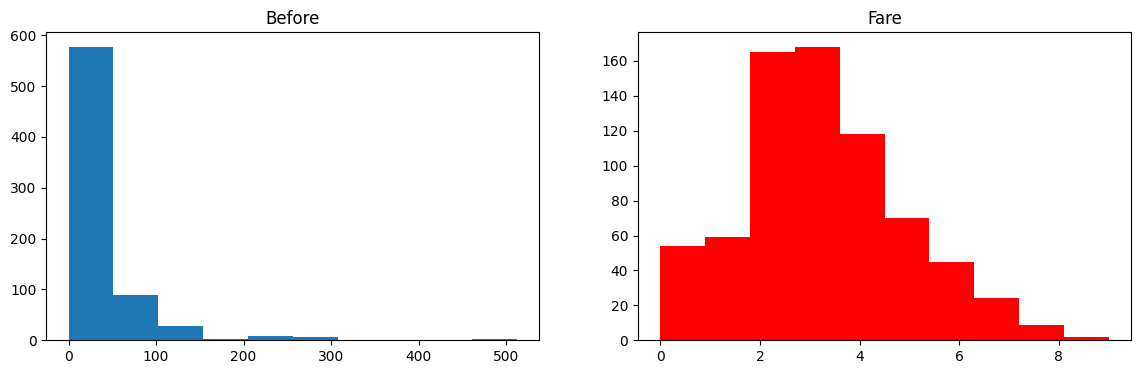

In [98]:
discretize(10,"kmeans")

#  Binarization ->

In [99]:
import numpy as np
import pandas as pd

In [100]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer

In [101]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Desktop\New folder (2)\train.csv" ,usecols  = ['Age', 'Fare', "SibSp", 'Parch', 'Survived'])

In [102]:
df.dropna(inplace=True)

In [103]:
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [104]:
df["family"] = df["SibSp"] + df["Parch"]  # family column banaya hai jisme sibling + parent child ka data hai.
df.head()

,Survived,Age,SibSp,Parch,Fare,family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [105]:
df.drop(columns=["SibSp","Parch"], inplace=True)
df.head()


,Survived,Age,Fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [107]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [108]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [109]:
X_train.head()

,Age,Fare,family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [110]:
# without binarization ->
clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6363636363636364

In [111]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv = 10,scoring="accuracy"))

np.float64(0.6470852895148671)

In [112]:
# Applying Binarization
from sklearn.preprocessing import Binarizer

In [113]:
trf = ColumnTransformer([("bin",Binarizer(copy=False),["family"])],remainder="passthrough")

In [115]:
X_train_trf = trf.fit_transform(X_train)  
X_test_trf = trf.transform(X_test)

In [116]:
pd.DataFrame(X_train_trf,columns=["family_bin","Age","Fare"])

,family_bin,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [117]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)
accuracy_score(y_test,y_pred2)

0.5874125874125874

In [118]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv = 10,scoring="accuracy"))

np.float64(0.6276017214397497)